# Q11.
```{admonition}
:class: note
Write a `Python` function to perform matrix completion as outlined in the text. In each iteration, the function should keep track of the relative error, as well as the iteration count. Iterations should continue until the relative error is small enough or until some maximum number of iterations is reached (set a default value for this maximum number). Furthermore, there should be an option to print out the progress in each iteration.

Test your function on the `Boston` data. First, standardize the features to have mean zero and standard deviation one using the StandardScaler() function. Run an experiment where you randomly leave out an increasing (and nested) number of observations from $5\%$ to $30\%$, in steps of $5\%$. Apply with $M = 1, 2, \dots , 8$. Display the approximation error as a function of the fraction of observations that are missing, and the value of $M$ , averaged over $10$ repetitions of the experiment.

In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import pandas as pd
from joblib import Parallel, delayed
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [3]:
def matrix_completion(X:np.array,to_print=False,max_iter = 100, tolerance=1e-5,M=1):
    missing = np.isnan(X)
    nan_idx = np.where(missing)
    completed_X = X.copy()
    completed_X[nan_idx] = np.nanmean(completed_X,axis=0)[nan_idx[1]]

    iteration = 0
    rel_error = 1
    mss0 = np.mean(X[~missing]**2)
    mss_old = np.mean(completed_X[~missing]**2)
    
    for k in range(max_iter):
        iteration += 1
        pca = PCA(n_components=M)
        z = pca.fit_transform(completed_X)
        phi = pca.components_
        X_approx = z@phi
        completed_X[missing] = X_approx[missing]
        mss = mean_squared_error(completed_X,X_approx) #Missing data points are subtracted to 0 and do not contribute to sum
        rel_error = np.abs((mss_old-mss)/mss0)
        mss_old = mss
        if to_print:
            print(f'Iteration {iteration}: MSS = {mss:.4f}, relative error = {rel_error:.2E}')
        if rel_error < tolerance:
            break

    return completed_X

In [4]:
boston = pd.read_csv('../../../ALL CSV FILES - 2nd Edition/Boston.csv',index_col=0)
scale = StandardScaler()
boston = scale.fit_transform(boston)

experiment_total = 10
M_max = 8
perc_max = 6
total_cells = boston.shape[0]*boston.shape[1]
five_perc = int(total_cells*.05)

In [5]:
def run_experiment(experiment_id):
    errors = np.zeros(shape=(M_max,perc_max))
    rng = np.random.default_rng(1728*experiment_id)
    dropout_selection = rng.choice(total_cells,five_perc*6,replace=False)
    for M in range(1,M_max+1):
        boston_exper = boston.copy()
        for i in range(perc_max):
            boston_exper.flat[dropout_selection[:five_perc*(i+1)]] = np.nan
            is_missing = np.isnan(boston_exper)
            true_val = boston[is_missing]
            boston_imputed = matrix_completion(boston_exper,M=M)[is_missing]
            errors[M-1,i] = mean_squared_error(true_val,boston_imputed)
    return errors

In [6]:
res = np.array(Parallel(n_jobs=-1)(delayed(run_experiment)(exper) for exper in range(experiment_total)))

In [7]:
experiment_df = pd.DataFrame(res.mean(axis=0),index=range(1,9),columns=np.round(np.linspace(0.05,0.3,6),2))
experiment_df

,0.05,0.10,0.15,0.20,0.25,0.30
1,0.646854,0.588662,0.603835,0.613988,0.612059,0.614470
2,0.583018,0.546212,0.571413,0.591729,0.608980,0.621038
3,0.531488,0.516880,0.547206,0.604860,0.641019,0.696556
4,0.971914,1.057744,0.995577,0.991313,1.128007,1.142988
5,1.488738,1.277469,1.331121,1.355246,1.391346,1.370967
6,1.366872,1.456587,1.658528,1.564929,1.525879,1.543310
7,1.101266,1.363495,1.377430,1.474229,1.579503,1.560716
8,1.457197,1.717772,1.738252,1.783074,1.690878,1.592791


In [8]:
experiment_df = pd.DataFrame(res.mean(axis=0),index=range(1,9),columns=np.round(np.linspace(0.05,0.3,6),2))
experiment_df

,0.05,0.10,0.15,0.20,0.25,0.30
1,0.646854,0.588662,0.603835,0.613988,0.612059,0.614470
2,0.583018,0.546212,0.571413,0.591729,0.608980,0.621038
3,0.531488,0.516880,0.547206,0.604860,0.641019,0.696556
4,0.971914,1.057744,0.995577,0.991313,1.128007,1.142988
5,1.488738,1.277469,1.331121,1.355246,1.391346,1.370967
6,1.366872,1.456587,1.658528,1.564929,1.525879,1.543310
7,1.101266,1.363495,1.377430,1.474229,1.579503,1.560716
8,1.457197,1.717772,1.738252,1.783074,1.690878,1.592791


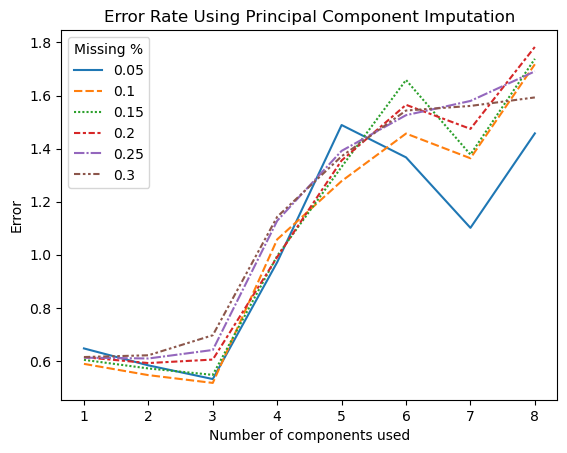

In [9]:
sns.lineplot(experiment_df)
plt.xlabel('Number of components used')
plt.ylabel('Error')
plt.legend(title='Missing %')
plt.title('Error Rate Using Principal Component Imputation')
plt.show()